# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [1]:
!curl -L -o ./heart-disease-data.zip \
  https://www.kaggle.com/api/v1/datasets/download/redwankarimsony/heart-disease-data

!unzip -o ./heart-disease-data.zip
!cp -f ./heart_disease_uci.csv ./heartdiseaseuci_raw.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 12672  100 12672    0     0   5772      0  0:00:02  0:00:02 --:--:--     0
Archive:  ./heart-disease-data.zip
  inflating: heart_disease_uci.csv   


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,r2_score,mean_squared_error
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
df = pd.read_csv("heartdiseaseuci_raw.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [11]:
def check_dataset(df: pd.DataFrame) -> None:
    n_rows, n_cols = df.shape
    print(f"Dataset shape: {n_rows} Rows x {n_cols} Columns", end='\n\n')
    print(f"Duplicate rows: {df.duplicated().sum()}", end='\n\n')
    print("Column Information:")
    info_table = pd.DataFrame(
        {
            "DataType": df.dtypes,
            "Missing Values Count": df.isnull().sum(),
            "Unique Values Count": df.nunique(dropna=True),
        }
    )
    print(info_table, end='\n\n')
    print("Summary statistics:")
    print(df.describe(include="all"), end='\n\n')
    print("5 row from dataset:")
    print(df.head(5))


Shape of Dataset: 920 Rows x 16 Columns

Column Information:
         DataType  Null Count  Null %  Unique Values  Unique %
id          int64           0    0.00            920    100.00
age         int64           0    0.00             50      5.43
sex        object           0    0.00              2      0.22
dataset    object           0    0.00              4      0.43
cp         object           0    0.00              4      0.43
trestbps  float64          59    6.41             61      6.63
chol      float64          30    3.26            217     23.59
fbs        object          90    9.78              2      0.22
restecg    object           2    0.22              3      0.33
thalch    float64          55    5.98            119     12.93
exang      object          55    5.98              2      0.22
oldpeak   float64          62    6.74             53      5.76
slope      object         309   33.59              3      0.33
ca        float64         611   66.41              4    

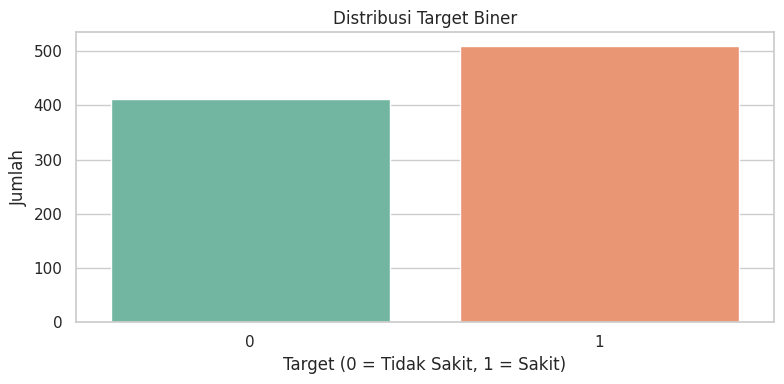

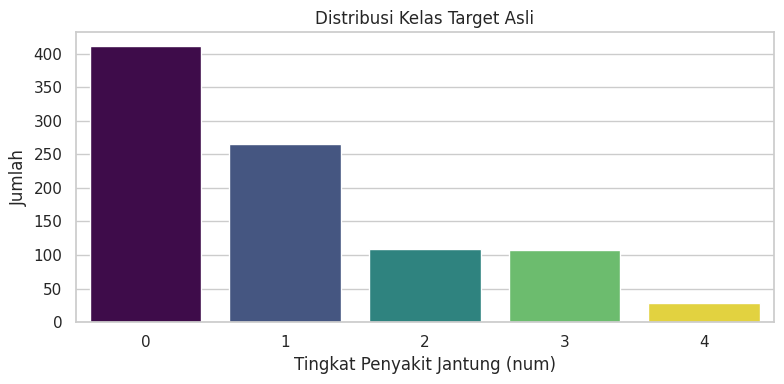

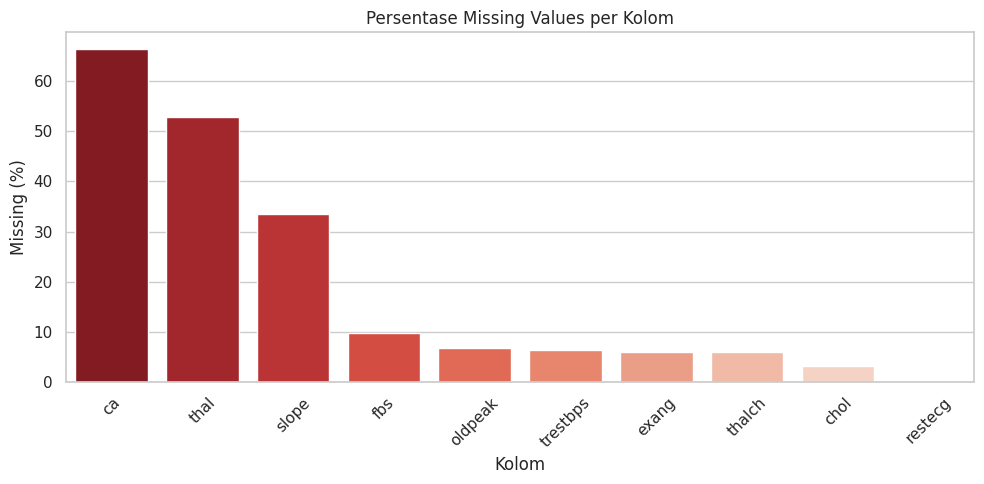

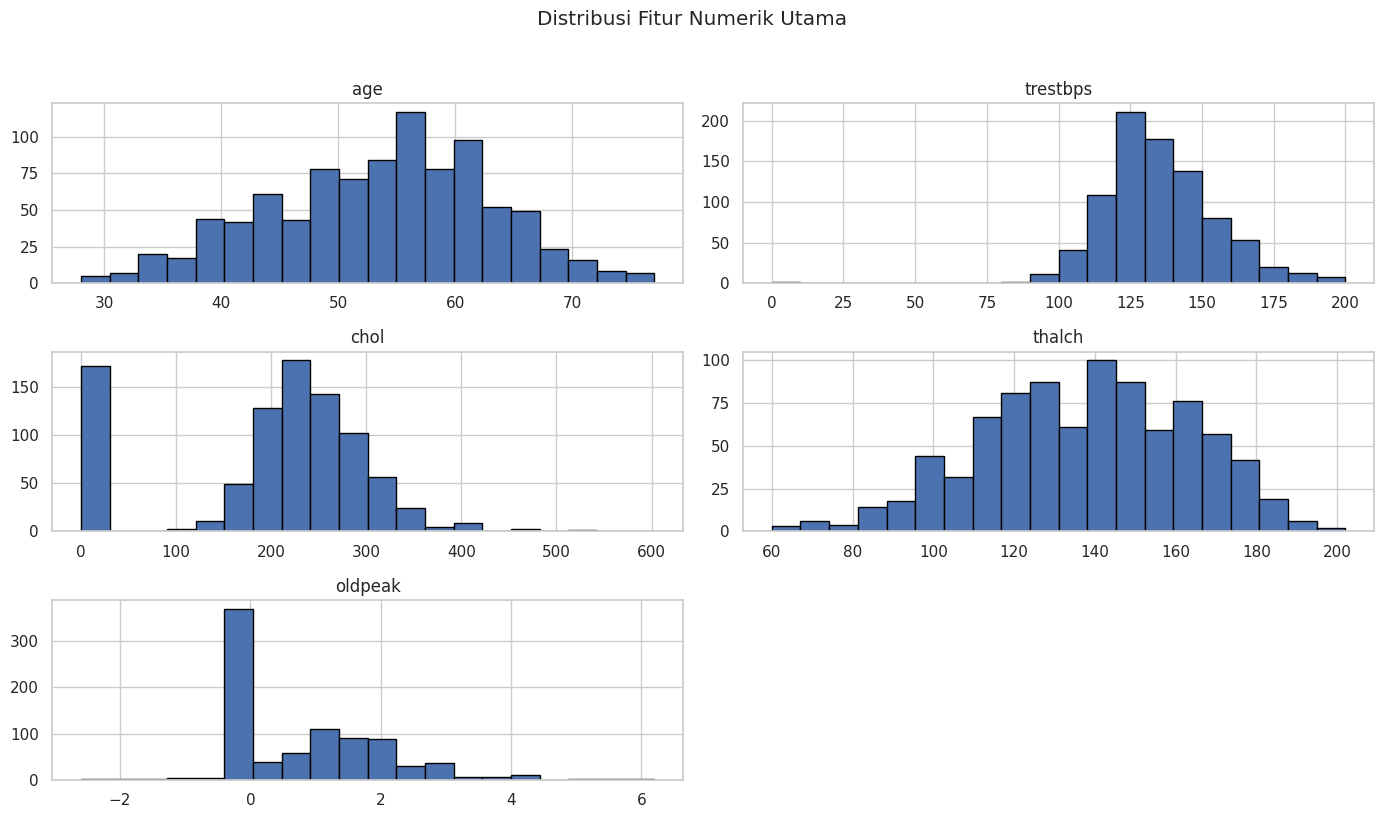

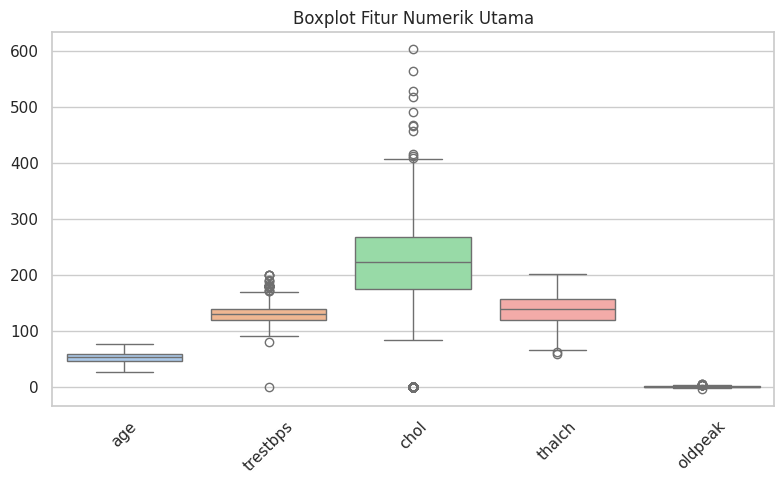

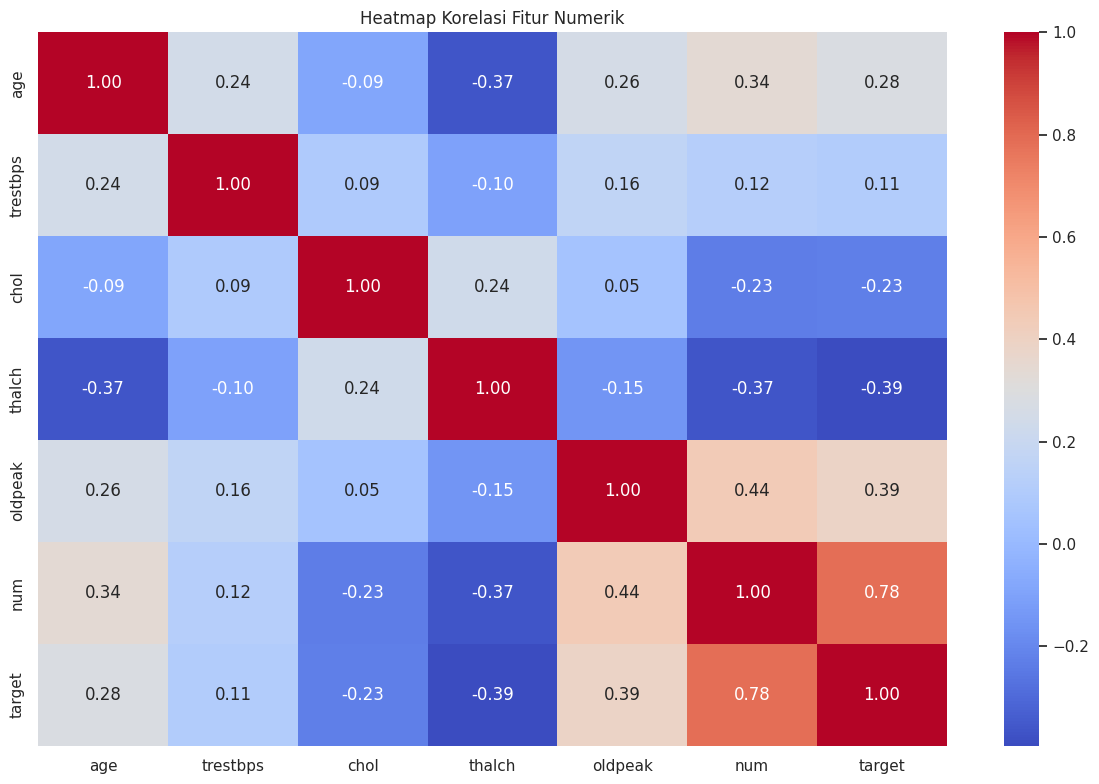

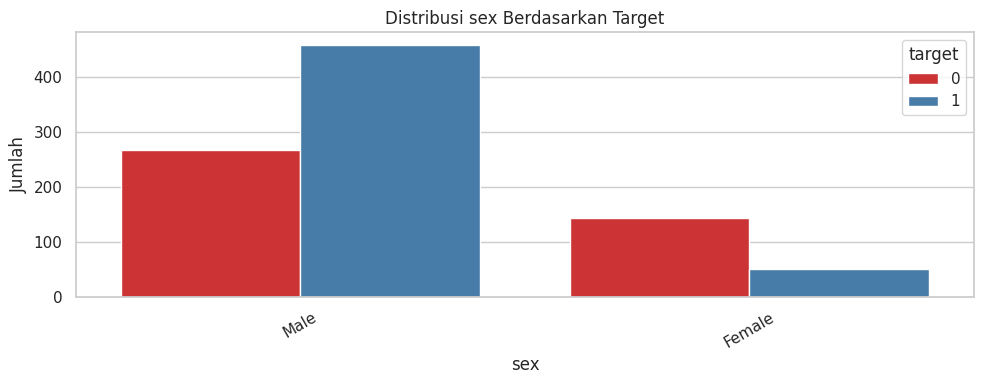

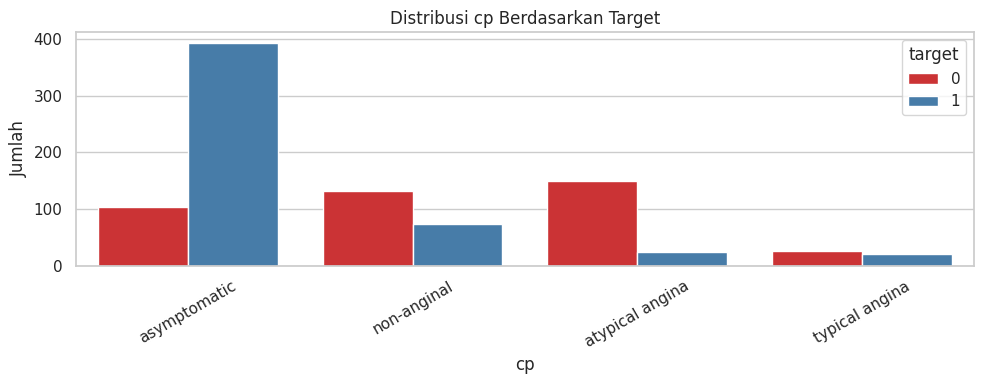

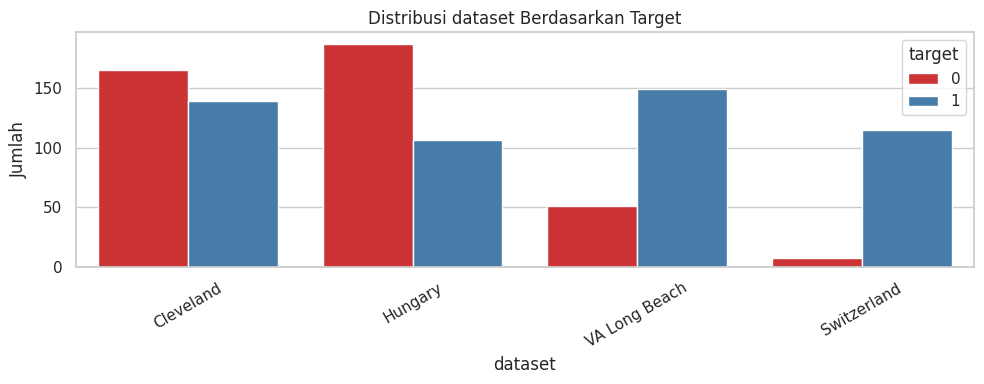

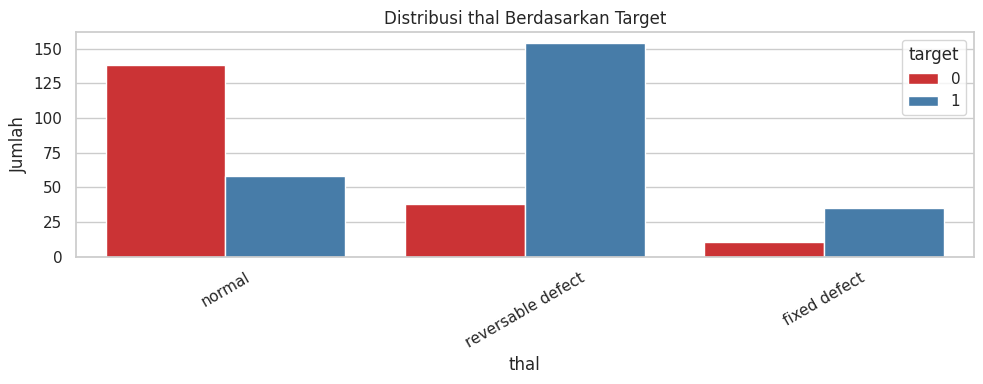

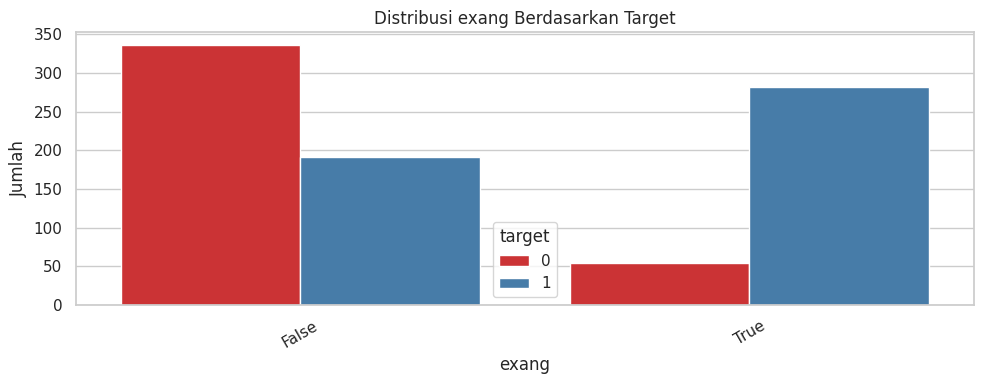

In [9]:
check_dataset(df)


numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("\nNumerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

print("\nNumerical Summary:")
print(df[numerical_cols].describe().T)

if categorical_cols:
    print("\nCategorical Summary:")
    print(df[categorical_cols].describe().T)

# Tambahkan target biner agar analisis penyakit jantung lebih mudah dibaca.
df["target"] = np.where(df["num"] > 0, 1, 0)

print("\nTarget Distribution (Original - num):")
print(df["num"].value_counts().sort_index())

print("\nTarget Distribution (Binary - target):")
print(df["target"].value_counts().sort_index())

print("\nMissing Values by Column:")
missing_table = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
missing_table["missing_pct"] = (missing_table["missing_count"] / len(df) * 100).round(2)
print(missing_table[missing_table["missing_count"] > 0])

if sns is not None:
    sns.set_theme(style="whitegrid")
else:
    plt.style.use("ggplot")

plt.figure(figsize=(8, 4))
target_counts = df["target"].value_counts().sort_index()
if sns is not None:
    sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, palette="Set2", legend=False)
else:
    plt.bar(target_counts.index.astype(str), target_counts.values, color=["#66c2a5", "#fc8d62"])
plt.title("Distribusi Target Biner")
plt.xlabel("Target (0 = Tidak Sakit, 1 = Sakit)")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
num_counts = df["num"].value_counts().sort_index()
if sns is not None:
    sns.barplot(x=num_counts.index, y=num_counts.values, hue=num_counts.index, palette="viridis", legend=False)
else:
    plt.bar(num_counts.index.astype(str), num_counts.values, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(num_counts))))
plt.title("Distribusi Kelas Target Asli")
plt.xlabel("Tingkat Penyakit Jantung (num)")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
missing_pct = missing_table[missing_table["missing_count"] > 0]
if not missing_pct.empty:
    if sns is not None:
        sns.barplot(
            x=missing_pct.index,
            y=missing_pct["missing_pct"],
            hue=missing_pct.index,
            palette="Reds_r",
            legend=False,
        )
    else:
        plt.bar(missing_pct.index, missing_pct["missing_pct"], color="#d62728")
    plt.title("Persentase Missing Values per Kolom")
    plt.xlabel("Kolom")
    plt.ylabel("Missing (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\nTidak ada missing values pada dataset.")

key_numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
available_key_numeric_cols = [col for col in key_numeric_cols if col in df.columns]

if available_key_numeric_cols:
    df[available_key_numeric_cols].hist(figsize=(14, 8), bins=20, edgecolor="black")
    plt.suptitle("Distribusi Fitur Numerik Utama", y=1.02)
    plt.tight_layout()
    plt.show()

if available_key_numeric_cols:
    plt.figure(figsize=(8, 5))
    if sns is not None:
        sns.boxplot(data=df[available_key_numeric_cols], palette="pastel")
    else:
        plt.boxplot([df[col].dropna() for col in available_key_numeric_cols], tick_labels=available_key_numeric_cols)
    plt.title("Boxplot Fitur Numerik Utama")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if available_key_numeric_cols:
    plt.figure(figsize=(12, 8))
    correlation_matrix = df[available_key_numeric_cols + ["num", "target"]].corr(numeric_only=True)
    if sns is not None:
        sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    else:
        plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
        plt.colorbar()
        plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
        plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
        for i in range(len(correlation_matrix.index)):
            for j in range(len(correlation_matrix.columns)):
                plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")
    plt.title("Heatmap Korelasi Fitur Numerik")
    plt.tight_layout()
    plt.show()

for col in ["sex", "cp", "dataset", "thal", "exang"]:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        crosstab = pd.crosstab(df[col], df["target"]).reindex(df[col].value_counts().index)
        if sns is not None:
            sns.countplot(data=df, x=col, hue="target", order=crosstab.index, palette="Set1")
        else:
            crosstab.plot(kind="bar", ax=plt.gca(), color=["#4daf4a", "#e41a1c"])
        plt.title(f"Distribusi {col} Berdasarkan Target")
        plt.xlabel(col)
        plt.ylabel("Jumlah")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
check_dataset(df)

Dataset shape: 920 Rows x 16 Columns

Duplicate rows: 0

Column Information:
         DataType  Missing Values Count  Unique Values Count
id          int64                     0                  920
age         int64                     0                   50
sex        object                     0                    2
dataset    object                     0                    4
cp         object                     0                    4
trestbps  float64                    59                   61
chol      float64                    30                  217
fbs        object                    90                    2
restecg    object                     2                    3
thalch    float64                    55                  119
exang      object                    55                    2
oldpeak   float64                    62                   53
slope      object                   309                    3
ca        float64                   611                    4
thal    

In [15]:
RANDOM_STATE = 42
TARGET_COLUMN = "num"
DROP_COLUMNS = ["id", "dataset"]

STRING_CATEGORICAL_FEATURES = ["sex", "cp", "restecg", "slope", "thal"]
NUMERIC_FEATURES = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
BOOL_FEATURES = ["fbs", "exang"]
OUTPUT_DIR = "./"
TEST_SIZE = 0.2

In [17]:
def clean_raw_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df.drop(columns=DROP_COLUMNS, errors="ignore")

    # convert to boolean type.
    for col in BOOL_FEATURES:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace(
                    {
                        "true": True,
                        "false": False,
                        "1": True,
                        "0": False,
                        "yes": True,
                        "no": False,
                        "nan": np.nan,
                        "none": np.nan,
                    }
                )
            )

    # convert to numeric type
    for col in NUMERIC_FEATURES:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")

    df = df.drop_duplicates()
    df = df.dropna(subset=[TARGET_COLUMN])

    # Target biner:
    # 0 = tidak terindikasi heart disease
    # 1 = terindikasi heart disease, dari num 1/2/3/4
    df[TARGET_COLUMN] = (df[TARGET_COLUMN] > 0).astype(int)

    return df

In [19]:
def build_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                IterativeImputer(
                    estimator=RandomForestRegressor(
                        n_estimators=100,
                        max_depth=None,
                        min_samples_leaf=5,
                        max_features=1.0,
                        bootstrap=True,
                        max_samples=0.5,
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                    max_iter=20,
                    tol=0.001,
                    initial_strategy="median",
                    imputation_order="ascending",
                    random_state=RANDOM_STATE,
                ),
            ),
            ("scaler", StandardScaler()),
        ]
    )

    string_categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )

    bool_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                    drop="if_binary",
                ),
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERIC_FEATURES),
            ("cat", string_categorical_pipeline, STRING_CATEGORICAL_FEATURES),
            ("bool", bool_pipeline, BOOL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return preprocessor

In [21]:
data = clean_raw_data(df)

X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN].astype(int)

check_dataset(data)

Dataset shape: 918 Rows x 14 Columns

Duplicate rows: 0

Column Information:
         DataType  Missing Values Count  Unique Values Count
age         int64                     0                   50
sex        object                     0                    2
cp         object                     0                    4
trestbps  float64                    59                   61
chol      float64                    29                  217
fbs        object                    90                    2
restecg    object                     2                    3
thalch    float64                    55                  119
exang      object                    55                    2
oldpeak   float64                    62                   53
slope      object                   307                    3
ca        float64                   609                    4
thal       object                   484                    3
num         int64                     0                    2

Summary

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

preprocessor = build_preprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)
y_train_df = pd.DataFrame({TARGET_COLUMN: y_train.reset_index(drop=True)})
y_test_df = pd.DataFrame({TARGET_COLUMN: y_test.reset_index(drop=True)})

check_dataset(X_train_df)

Dataset shape: 734 Rows x 23 Columns

Duplicate rows: 0

Column Information:
                         DataType  Missing Values Count  Unique Values Count
age                       float64                     0                   50
trestbps                  float64                     0                  108
chol                      float64                     0                  235
thalch                    float64                     0                  163
oldpeak                   float64                     0                  100
ca                        float64                     0                  484
sex_Female                float64                     0                    2
sex_Male                  float64                     0                    2
cp_asymptomatic           float64                     0                    2
cp_atypical angina        float64                     0                    2
cp_non-anginal            float64                     0                    2

In [25]:
X_train_df.to_csv(os.path.join(OUTPUT_DIR, "X_train.csv"), index=False)
X_test_df.to_csv(os.path.join(OUTPUT_DIR, "X_test.csv"), index=False)
y_train_df.to_csv(os.path.join(OUTPUT_DIR, "y_train.csv"), index=False)
y_test_df.to_csv(os.path.join(OUTPUT_DIR, "y_test.csv"), index=False)

joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, "preprocessor.joblib"))

['./preprocessor.joblib']